In [1]:
# # Evandro Ribeiro Gomes Coelho
# # TCCII

# packagess
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import math

from mpl_toolkits.mplot3d import Axes3D
from pandas_profiling import ProfileReport

In [2]:
# # import data

fl_path = 'data/'
fl_ext = '.csv'

fl_name = 'plfec-holidays'
df_holidays = pd.DataFrame(pd.read_csv(fl_path + fl_name + fl_ext, sep=';'))

fl_name = 'plfec-metadata'
df_metadata = pd.DataFrame(pd.read_csv(fl_path + fl_name + fl_ext, sep=';'))

fl_name = 'plfec-submission-forecast-period'
df_submission_forecast_period = pd.DataFrame(pd.read_csv(fl_path + fl_name + fl_ext, sep=';'))

fl_name = 'plfec-train-data'
df_train = pd.DataFrame(pd.read_csv(fl_path + fl_name + fl_ext, sep=';'))

fl_name = 'plfec-weather'
df_weather = pd.DataFrame(pd.read_csv(fl_path + fl_name + fl_ext, sep=';'))

# delete temp variables
del fl_name, fl_path, fl_ext

In [3]:
# triming the data
df_train['Date'] = pd.to_datetime(df_train['Timestamp'].str[:10])
df_holidays['Date'] = pd.to_datetime(df_holidays['Date'])

df_weather['Timestamp'] = pd.to_datetime(df_weather['Timestamp'])
df_train['Timestamp'] = pd.to_datetime(df_train['Timestamp'])

In [4]:
# df_holiday
df_holidays = df_holidays.groupby(['Date', 'SiteId']).agg({'Holiday':'count'}).reset_index().rename(columns={'Holiday': 'Holiday Flag'})
df_holidays['Holiday Flag'] = int(1)
df_holidays = df_holidays.sort_values(by=['SiteId', 'Date'])

In [5]:
# subset by SiteId

SiteId = 40
df_energy = df_train[df_train['SiteId'] == SiteId]
df_weather = df_weather[df_weather['SiteId'] == SiteId]
df_holidays = df_holidays[df_holidays['SiteId'] == SiteId]

In [6]:
# sort df_energy by Timestamp

df_energy = df_energy.sort_values(by=['SiteId','Timestamp'])

In [7]:
# get the closest weather value by distance in df_weather

# há mais de uma medida de Temperature para o mesmo SiteId na mesma Timestamp, de distâncias diferentes. Utilizado o valor da menor distância.
df_weather = df_weather.sort_values('Distance').drop_duplicates(subset=['SiteId', 'Timestamp'], keep='first')
df_weather = df_weather.sort_values(by=['Timestamp'])

In [8]:
# energy frequence of measure (minutes)
df_energy['freq_energy'] = df_energy['Timestamp'].diff().apply(lambda x: x/np.timedelta64(1, 'm')).fillna(0).astype('int64')

# weather frequence of measure (minutes)
df_weather['freq_weather'] = df_weather['Timestamp'].diff().apply(lambda x: x/np.timedelta64(1, 'm')).fillna(0).astype('int64')

In [9]:
df_energy.groupby(['freq_energy']).count()

,obs_id,SiteId,Timestamp,ForecastId,Value,Date
freq_energy,,,,,,
0,1,1,1,1,1,1
60,17334,17334,17334,17334,17211,17334
11580,17,17,17,17,17,17


In [10]:
# merge df with df_weather

df_merge1 = pd.merge(
    df_energy, # left
    df_weather, # right
    how="left",
    on=['SiteId', 'Timestamp'],
)

In [11]:
# merge df with df_holidays

df_merge2 = pd.merge(
    df_merge1,
    df_holidays,
    how="left",
    on=['Date', 'SiteId'],
)

In [12]:
# remane dfs and delete the aux merges

df = df_merge2
del df_merge1, df_merge2

In [13]:
# drop columns

df = df.drop(columns=['obs_id', 'SiteId', 'ForecastId', 'Date', 'freq_energy', 'freq_weather', 'Distance'])

In [14]:
df = df.set_index('Timestamp')

In [15]:
# Extract units of time from the timestamp
df['hour'] = df.index.hour
df['min'] = df.index.minute

In [16]:
# Create a time of day to represent hours and minutes
df['time'] = df['hour'] + (df['min'] / 60)

In [17]:
df['hr_sin'] = np.sin(df.time*(2.*np.pi/24))
df['hr_cos'] = np.cos(df.time*(2.*np.pi/24))

In [18]:
df = df.fillna(0)

In [19]:
df

,Value,Temperature,Holiday Flag,hour,min,time,hr_sin,hr_cos
Timestamp,,,,,,,,
2015-07-03 14:30:00+00:00,6997.984367,31.0,0.0,14,30,14.5,-0.608761,-0.793353
2015-07-03 15:30:00+00:00,15518.012898,33.0,0.0,15,30,15.5,-0.793353,-0.608761
2015-07-03 16:30:00+00:00,6674.491991,34.0,0.0,16,30,16.5,-0.923880,-0.382683
2015-07-03 17:30:00+00:00,4920.282616,33.0,0.0,17,30,17.5,-0.991445,-0.130526
2015-07-03 18:30:00+00:00,4118.787012,34.0,0.0,18,30,18.5,-0.991445,0.130526
...,...,...,...,...,...,...,...,...
2017-11-08 09:30:00+00:00,9823.167728,6.0,0.0,9,30,9.5,0.608761,-0.793353
2017-11-08 10:30:00+00:00,9813.048374,6.0,0.0,10,30,10.5,0.382683,-0.923880
2017-11-08 11:30:00+00:00,11714.319199,7.0,0.0,11,30,11.5,0.130526,-0.991445


In [20]:
df2 = df
df2 = df2.rename(columns={'Value':'Consumo',
                          'Temperature':'Temperatura',
                          'Holiday Flag':'Marcação Feriado',
                          'hour':'Hora',
                          'min':'Minuto',
                          'time':'Tempo',
                          'hr_sin':'Hora Seno',
                          'hr_cos':'Hora Cosseno'})

In [21]:
df2.head()

,Consumo,Temperatura,Marcação Feriado,Hora,Minuto,Tempo,Hora Seno,Hora Cosseno
Timestamp,,,,,,,,
2015-07-03 14:30:00+00:00,6997.984367,31.0,0.0,14,30,14.5,-0.608761,-0.793353
2015-07-03 15:30:00+00:00,15518.012898,33.0,0.0,15,30,15.5,-0.793353,-0.608761
2015-07-03 16:30:00+00:00,6674.491991,34.0,0.0,16,30,16.5,-0.923880,-0.382683
2015-07-03 17:30:00+00:00,4920.282616,33.0,0.0,17,30,17.5,-0.991445,-0.130526
2015-07-03 18:30:00+00:00,4118.787012,34.0,0.0,18,30,18.5,-0.991445,0.130526


Text(0, 0.5, 'Tempo Seno')

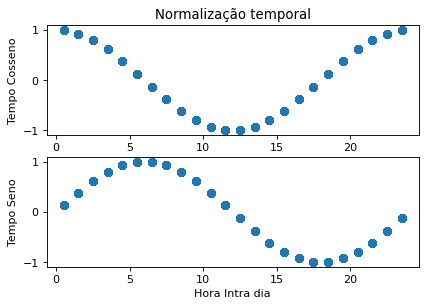

In [22]:
plt.figure(dpi=80)
plt.subplot(2, 1, 1)
plt.scatter(df['time'], df['hr_cos'])
plt.xlabel("Hora Intra dia")
plt.ylabel("Tempo Cosseno")
plt.title('Normalização temporal')

plt.subplot(2, 1, 2)
plt.scatter(df['time'], df['hr_sin'])
plt.xlabel("Hora Intra dia")
plt.ylabel("Tempo Seno")

Text(0.5, 1.0, 'Normalização temporal Cosseno')

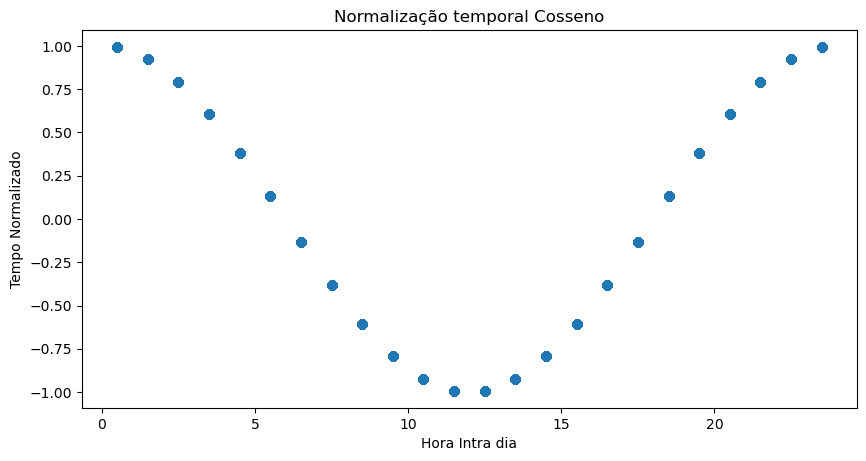

In [23]:
plt.figure(dpi=100, figsize=(10,5))
plt.scatter(df['time'], df['hr_cos'])
plt.xlabel("Hora Intra dia")
plt.ylabel("Tempo Normalizado")
plt.title('Normalização temporal Cosseno')

Text(0.5, 1.0, 'Normalização temporal Seno')

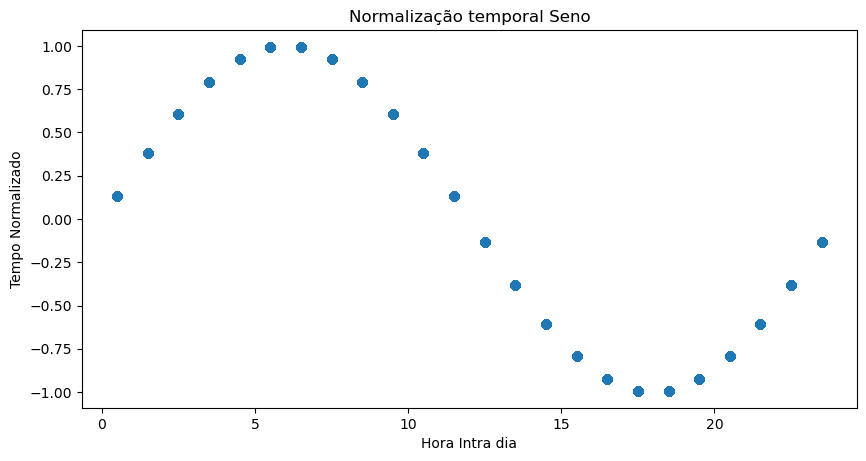

In [24]:
plt.figure(dpi=100, figsize=(10,5))
plt.scatter(df['time'], df['hr_sin'])
plt.xlabel("Hora Intra dia")
plt.ylabel("Tempo Normalizado")
plt.title('Normalização temporal Seno')

Text(0.5, 1.0, 'Energia no tempo')

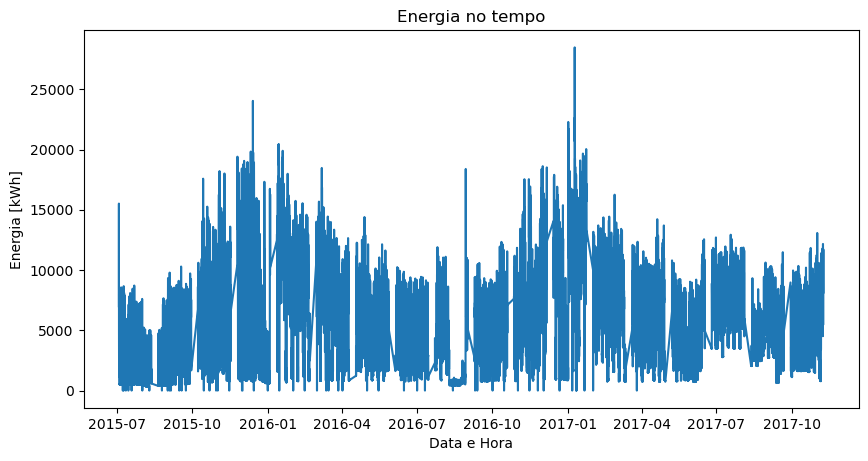

In [25]:
plt.figure(dpi=100, figsize=(10,5))
plt.plot(df.index, df['Value'])
plt.xlabel("Data e Hora")
plt.ylabel("Energia [kWh]")
plt.title('Energia no tempo')

Text(0.5, 1.0, 'Energia no dia 2016-09-20')

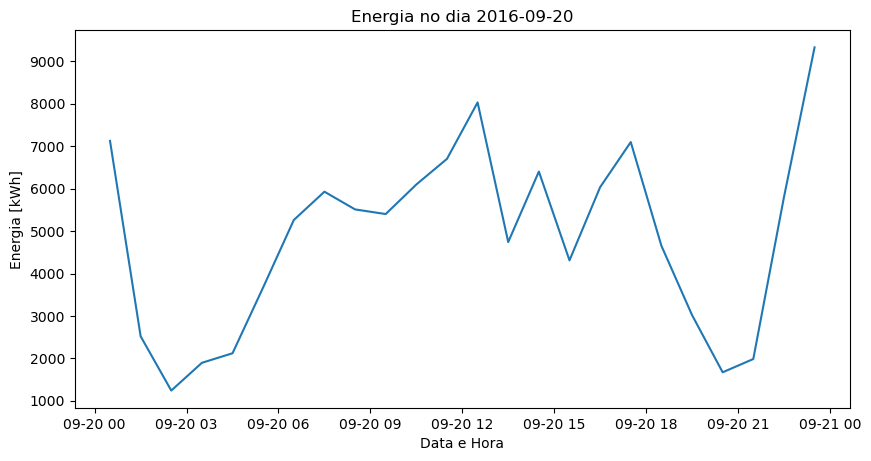

In [26]:
plt.figure(dpi=100, figsize=(10,5))
plt.plot(df[df.index.date.astype(str) == '2016-09-20']['Value'])
plt.xlabel("Data e Hora")
plt.ylabel("Energia [kWh]")
plt.title('Energia no dia 2016-09-20')

Text(0.5, 1.0, 'Temperatura no tempo')

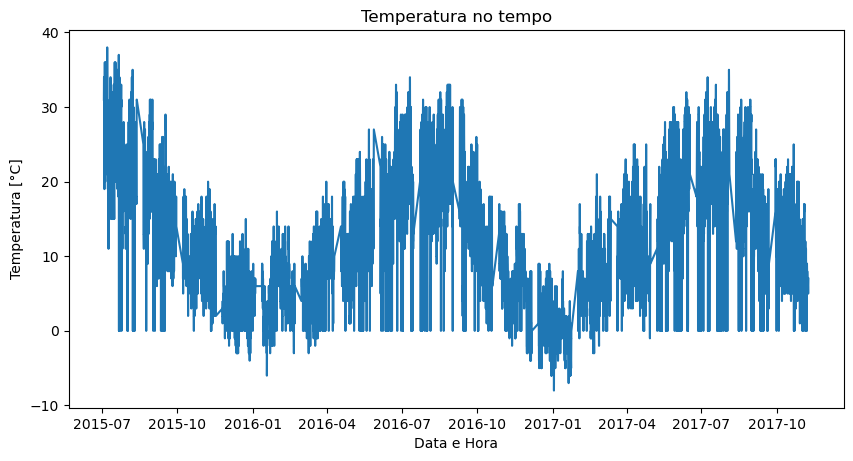

In [27]:
plt.figure(dpi=100, figsize=(10,5))
plt.plot(df.index, df['Temperature'])
plt.xlabel("Data e Hora")
plt.ylabel("Temperatura [°C]")
plt.title('Temperatura no tempo')

Text(0.5, 1.0, 'Temperatura no dia 2016-09-20')

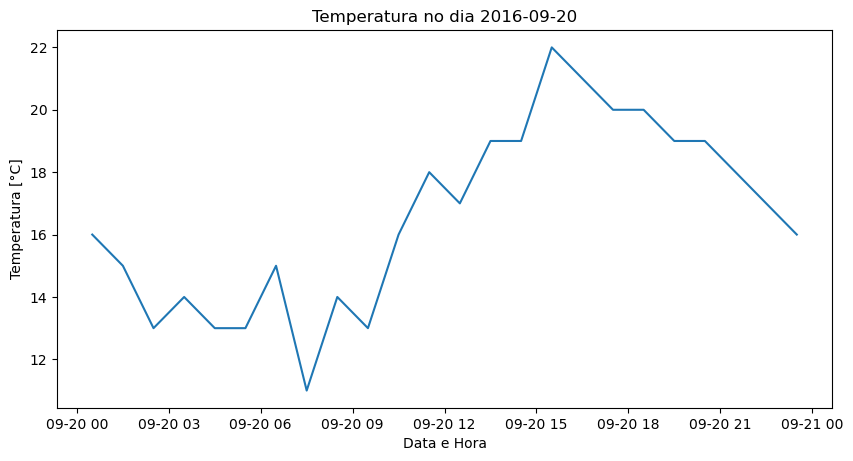

In [28]:
plt.figure(dpi=100, figsize=(10,5))
plt.plot(df[df.index.date.astype(str) == '2016-09-20']['Temperature'])
plt.xlabel("Data e Hora")
plt.ylabel("Temperatura [°C]")
plt.title('Temperatura no dia 2016-09-20')

Text(0.5, 0, 'Temperatura [°C]')

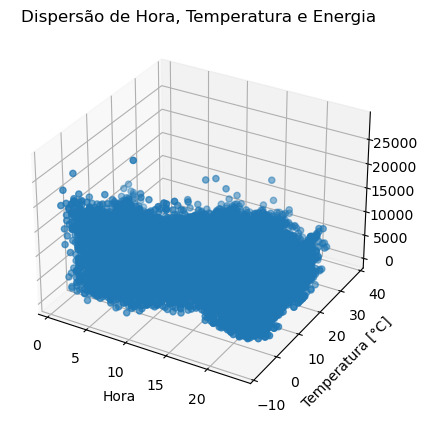

In [29]:
# plot 3D matrix 

fig = plt.figure(dpi=100, figsize=(10,5))
ax = fig.gca(projection='3d')
ax.scatter(df['time'],
           df['Temperature'],
           df['Value'])
plt.title('Dispersão de Hora, Temperatura e Energia')
plt.xlabel('Hora')
plt.ylabel('Temperatura [°C]')

In [30]:
df

,Value,Temperature,Holiday Flag,hour,min,time,hr_sin,hr_cos
Timestamp,,,,,,,,
2015-07-03 14:30:00+00:00,6997.984367,31.0,0.0,14,30,14.5,-0.608761,-0.793353
2015-07-03 15:30:00+00:00,15518.012898,33.0,0.0,15,30,15.5,-0.793353,-0.608761
2015-07-03 16:30:00+00:00,6674.491991,34.0,0.0,16,30,16.5,-0.923880,-0.382683
2015-07-03 17:30:00+00:00,4920.282616,33.0,0.0,17,30,17.5,-0.991445,-0.130526
2015-07-03 18:30:00+00:00,4118.787012,34.0,0.0,18,30,18.5,-0.991445,0.130526
...,...,...,...,...,...,...,...,...
2017-11-08 09:30:00+00:00,9823.167728,6.0,0.0,9,30,9.5,0.608761,-0.793353
2017-11-08 10:30:00+00:00,9813.048374,6.0,0.0,10,30,10.5,0.382683,-0.923880
2017-11-08 11:30:00+00:00,11714.319199,7.0,0.0,11,30,11.5,0.130526,-0.991445


In [31]:
df_prof = df[['Value', 'Temperature', 'hr_sin', 'hr_cos']]
df_prof

,Value,Temperature,hr_sin,hr_cos
Timestamp,,,,
2015-07-03 14:30:00+00:00,6997.984367,31.0,-0.608761,-0.793353
2015-07-03 15:30:00+00:00,15518.012898,33.0,-0.793353,-0.608761
2015-07-03 16:30:00+00:00,6674.491991,34.0,-0.923880,-0.382683
2015-07-03 17:30:00+00:00,4920.282616,33.0,-0.991445,-0.130526
2015-07-03 18:30:00+00:00,4118.787012,34.0,-0.991445,0.130526
...,...,...,...,...
2017-11-08 09:30:00+00:00,9823.167728,6.0,0.608761,-0.793353
2017-11-08 10:30:00+00:00,9813.048374,6.0,0.382683,-0.923880
2017-11-08 11:30:00+00:00,11714.319199,7.0,0.130526,-0.991445


In [32]:
df_prof = df_prof.rename(columns={'Value': 'Consumo', 'Temperature':'Temperatura','hr_sin':'Hora Seno','hr_cos':'Hora Cosseno'})

In [33]:
profile = ProfileReport(df_prof, title="Pandas Profiling Report", explorative=True)
profile

In [34]:
profile.to_file("correlations.html")

In [35]:
#save to csv
# saving data to csv

df.to_csv('data/df_mlp.csv', index=True, header=True)

In [36]:
from matplotlib import pyplot
from math import cos, sin, atan


class Neuron():
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def draw(self, neuron_radius):
        circle = pyplot.Circle((self.x, self.y), radius=neuron_radius, fill=False)
        pyplot.gca().add_patch(circle)


class Layer():
    def __init__(self, network, number_of_neurons, number_of_neurons_in_widest_layer):
        self.vertical_distance_between_layers = 6
        self.horizontal_distance_between_neurons = 2
        self.neuron_radius = 0.5
        self.number_of_neurons_in_widest_layer = number_of_neurons_in_widest_layer
        self.previous_layer = self.__get_previous_layer(network)
        self.y = self.__calculate_layer_y_position()
        self.neurons = self.__intialise_neurons(number_of_neurons)

    def __intialise_neurons(self, number_of_neurons):
        neurons = []
        x = self.__calculate_left_margin_so_layer_is_centered(number_of_neurons)
        for iteration in range(number_of_neurons):
            neuron = Neuron(x, self.y)
            neurons.append(neuron)
            x += self.horizontal_distance_between_neurons
        return neurons

    def __calculate_left_margin_so_layer_is_centered(self, number_of_neurons):
        return self.horizontal_distance_between_neurons * (self.number_of_neurons_in_widest_layer - number_of_neurons) / 2

    def __calculate_layer_y_position(self):
        if self.previous_layer:
            return self.previous_layer.y + self.vertical_distance_between_layers
        else:
            return 0

    def __get_previous_layer(self, network):
        if len(network.layers) > 0:
            return network.layers[-1]
        else:
            return None

    def __line_between_two_neurons(self, neuron1, neuron2):
        angle = atan((neuron2.x - neuron1.x) / float(neuron2.y - neuron1.y))
        x_adjustment = self.neuron_radius * sin(angle)
        y_adjustment = self.neuron_radius * cos(angle)
        line = pyplot.Line2D((neuron1.x - x_adjustment, neuron2.x + x_adjustment), (neuron1.y - y_adjustment, neuron2.y + y_adjustment))
        pyplot.gca().add_line(line)

    def draw(self, layerType=0):
        for neuron in self.neurons:
            neuron.draw( self.neuron_radius )
            if self.previous_layer:
                for previous_layer_neuron in self.previous_layer.neurons:
                    self.__line_between_two_neurons(neuron, previous_layer_neuron)
        # write Text
        x_text = self.number_of_neurons_in_widest_layer * self.horizontal_distance_between_neurons
        if layerType == 0:
            pyplot.text(x_text, self.y, 'Input Layer', fontsize = 12)
        elif layerType == -1:
            pyplot.text(x_text, self.y, 'Output Layer', fontsize = 12)
        else:
            pyplot.text(x_text, self.y, 'Hidden Layer '+str(layerType), fontsize = 12)

class NeuralNetwork():
    def __init__(self, number_of_neurons_in_widest_layer):
        self.number_of_neurons_in_widest_layer = number_of_neurons_in_widest_layer
        self.layers = []
        self.layertype = 0

    def add_layer(self, number_of_neurons ):
        layer = Layer(self, number_of_neurons, self.number_of_neurons_in_widest_layer)
        self.layers.append(layer)

    def draw(self):
        pyplot.figure()
        for i in range( len(self.layers) ):
            layer = self.layers[i]
            if i == len(self.layers)-1:
                i = -1
            layer.draw( i )
        pyplot.axis('scaled')
        pyplot.axis('off')
        pyplot.title( 'Arquiterura da Rede Neural')
        pyplot.show()

class DrawNN():
    def __init__( self, neural_network ):
        self.neural_network = neural_network

    def draw( self ):
        widest_layer = max( self.neural_network )
        network = NeuralNetwork( widest_layer )
        for l in self.neural_network:
            network.add_layer(l)
        network.draw()

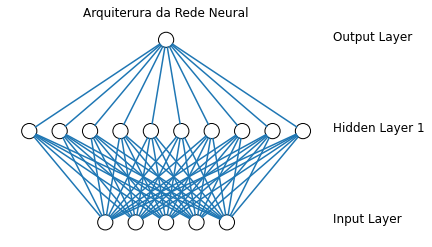

In [37]:
network = DrawNN( [5,10,1] )
network.draw()